In [53]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/carprice_assignment.csv")
df.head(1)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0


In [54]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [55]:
t1 = {'car_ID':'번호', 'symboling':'보험위험등급', 'CarName':'브랜드', 'fueltype':'연료타입', 'aspiration':'흡입방식',
       'doornumber':'문개수', 'carbody':'바디타입', 'drivewheel':'휠타입', 'enginelocation':'엔진위치', 'wheelbase':'휠베이스',
       'carlength':'차량길이', 'carwidth':'차량폭', 'carheight':'차량높이', 'curbweight':'공차중량', 'enginetype':'엔진타입',
       'cylindernumber':'실린더수', 'enginesize':'엔진사이즈', 'fuelsystem':'연료시스템', 'boreratio':'실린더지름비율', 'stroke':'피스톤스토로크',
       'compressionratio':'압축비', 'horsepower':'마력', 'peakrpm':'최대회전수', 'citympg':'시내연비', 'highwaympg':'고속도로연비',
       'price':'출고가'}

df.rename(columns=t1, inplace=True)
df.head(1)

,번호,보험위험등급,브랜드,연료타입,흡입방식,문개수,바디타입,휠타입,엔진위치,휠베이스,...,엔진사이즈,연료시스템,실린더지름비율,피스톤스토로크,압축비,마력,최대회전수,시내연비,고속도로연비,출고가
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0


In [56]:
# 결측치 확인
df.isnull().sum()

번호         0
보험위험등급     0
브랜드        0
연료타입       0
흡입방식       0
문개수        0
바디타입       0
휠타입        0
엔진위치       0
휠베이스       0
차량길이       0
차량폭        0
차량높이       0
공차중량       0
엔진타입       0
실린더수       0
엔진사이즈      0
연료시스템      0
실린더지름비율    0
피스톤스토로크    0
압축비        0
마력         0
최대회전수      0
시내연비       0
고속도로연비     0
출고가        0
dtype: int64

In [57]:
# 필요없는 컬럼 제거
t1 = [ '번호', '엔진위치', '문개수', ]

df1 = df.drop(columns=t1)

In [58]:
df1['브랜드'].value_counts()

브랜드
toyota corona           6
toyota corolla          6
peugeot 504             6
subaru dl               4
mitsubishi mirage g4    3
                       ..
mazda glc 4             1
mazda rx2 coupe         1
maxda glc deluxe        1
maxda rx3               1
volvo 246               1
Name: count, Length: 147, dtype: int64

In [59]:
# 브랜드에서 공백 기준으로 앞쪽만 보관
df1['브랜드'] = df1['브랜드'].str.split(" ").str[0]
df1

,보험위험등급,브랜드,연료타입,흡입방식,바디타입,휠타입,휠베이스,차량길이,차량폭,차량높이,...,엔진사이즈,연료시스템,실린더지름비율,피스톤스토로크,압축비,마력,최대회전수,시내연비,고속도로연비,출고가
0,3,alfa-romero,gas,std,convertible,rwd,88.6,168.8,64.1,48.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero,gas,std,convertible,rwd,88.6,168.8,64.1,48.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero,gas,std,hatchback,rwd,94.5,171.2,65.5,52.4,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi,gas,std,sedan,fwd,99.8,176.6,66.2,54.3,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi,gas,std,sedan,4wd,99.4,176.6,66.4,54.3,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,volvo,gas,std,sedan,rwd,109.1,188.8,68.9,55.5,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,-1,volvo,gas,turbo,sedan,rwd,109.1,188.8,68.8,55.5,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,-1,volvo,gas,std,sedan,rwd,109.1,188.8,68.9,55.5,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,-1,volvo,diesel,turbo,sedan,rwd,109.1,188.8,68.9,55.5,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [60]:
# 브랜드명 정규화
mapping = {
    'toyouta': 'toyota',
    'nissan': 'nissan',
    'maxda': 'mazda',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'porcshce': 'porsche'
}

df1['브랜드'] = ( df1['브랜드'].str.lower().replace(mapping) )

In [61]:
# 타입 확인
# 범주형 : 브랜드, 연료타입, 흡입방식, 바디타입, 휠타입, 엔진타입, 연료시스템
# 숫자형 : 실린더수
df1.dtypes

보험위험등급       int64
브랜드         object
연료타입        object
흡입방식        object
바디타입        object
휠타입         object
휠베이스       float64
차량길이       float64
차량폭        float64
차량높이       float64
공차중량         int64
엔진타입        object
실린더수        object
엔진사이즈        int64
연료시스템       object
실린더지름비율    float64
피스톤스토로크    float64
압축비        float64
마력           int64
최대회전수        int64
시내연비         int64
고속도로연비       int64
출고가        float64
dtype: object

In [62]:
t1 = {"four":4, "six":6, "five":5, "eight":8, "two":2, "three":3, "twelve":12}
df1['실린더수'] = df1['실린더수'].map(t1)
df1['실린더수'].value_counts()

실린더수
4     159
6      24
5      11
8       5
2       4
3       1
12      1
Name: count, dtype: int64

In [63]:
# LabelEncoder => 문자를 숫자로 변경, 값과 타입도 동시에 변경
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

t1 =['브랜드', '연료타입', '흡입방식', '바디타입', '휠타입', '엔진타입', '연료시스템']

for col in t1:
    df1[col] = label_encoder.fit_transform(df1[col])

df1.dtypes

보험위험등급       int64
브랜드          int64
연료타입         int64
흡입방식         int64
바디타입         int64
휠타입          int64
휠베이스       float64
차량길이       float64
차량폭        float64
차량높이       float64
공차중량         int64
엔진타입         int64
실린더수         int64
엔진사이즈        int64
연료시스템        int64
실린더지름비율    float64
피스톤스토로크    float64
압축비        float64
마력           int64
최대회전수        int64
시내연비         int64
고속도로연비       int64
출고가        float64
dtype: object

In [64]:
# onehot => 1 2 3
import pandas as pd

t1 =['브랜드', '연료타입', '흡입방식', '바디타입', '휠타입', '엔진타입', '연료시스템']

one_hot = pd.get_dummies(
    df1[t1].astype(str), dtype=int
)

one_hot

,브랜드_0,브랜드_1,브랜드_10,브랜드_11,브랜드_12,브랜드_13,브랜드_14,브랜드_15,브랜드_16,브랜드_17,...,엔진타입_5,엔진타입_6,연료시스템_0,연료시스템_1,연료시스템_2,연료시스템_3,연료시스템_4,연료시스템_5,연료시스템_6,연료시스템_7
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
201,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
202,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
203,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [65]:
# 기본 df1에서 t1 컬럼을 제거한 후 one_hot을 뒤쪽에 붙임
df2 = pd.concat([df1.drop(columns=t1), one_hot], axis=1)
df2.columns

Index(['보험위험등급', '휠베이스', '차량길이', '차량폭', '차량높이', '공차중량', '실린더수', '엔진사이즈',
       '실린더지름비율', '피스톤스토로크', '압축비', '마력', '최대회전수', '시내연비', '고속도로연비', '출고가',
       '브랜드_0', '브랜드_1', '브랜드_10', '브랜드_11', '브랜드_12', '브랜드_13', '브랜드_14',
       '브랜드_15', '브랜드_16', '브랜드_17', '브랜드_18', '브랜드_19', '브랜드_2', '브랜드_20',
       '브랜드_21', '브랜드_3', '브랜드_4', '브랜드_5', '브랜드_6', '브랜드_7', '브랜드_8', '브랜드_9',
       '연료타입_0', '연료타입_1', '흡입방식_0', '흡입방식_1', '바디타입_0', '바디타입_1', '바디타입_2',
       '바디타입_3', '바디타입_4', '휠타입_0', '휠타입_1', '휠타입_2', '엔진타입_0', '엔진타입_1',
       '엔진타입_2', '엔진타입_3', '엔진타입_4', '엔진타입_5', '엔진타입_6', '연료시스템_0', '연료시스템_1',
       '연료시스템_2', '연료시스템_3', '연료시스템_4', '연료시스템_5', '연료시스템_6', '연료시스템_7'],
      dtype='object')

In [66]:
y = df2['출고가'].values
y.shape

(205,)

In [67]:
x = df2.drop('출고가', axis=1).values
x.shape

(205, 64)

In [68]:
# 데이터 분할
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((164, 64), (41, 64), (164,), (41,))

In [69]:
# 평균을 0 편차를 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [70]:
# 모델 생성
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
# x1 * w1 + ..... 64 + b
print(f"회귀 계수 : {lr.coef_}")
print(f"절편 : {lr.intercept_}")

회귀 계수 : [-5.55277494e+01  1.79327925e+03 -1.31318053e+03  1.10339709e+03
 -5.33766152e+02  2.90110813e+03 -2.16663185e+02  5.35681278e+03
 -8.62718853e+02 -4.71784379e+02 -3.73920263e+03 -9.05253952e+02
  1.40685803e+03 -5.19425997e+00  1.64270343e+03  3.17039783e+02
  3.80675292e+02 -8.64877943e+00 -8.50779662e+02 -3.36719807e+02
 -5.25846737e+02 -5.70039102e+02  1.26400649e+03 -7.24500617e+01
  7.95921622e+02 -1.90184288e+03 -3.56767986e+02  1.75905596e+03
  1.30195680e+01  1.44683679e+02  7.00943598e+02  1.25567652e+02
 -6.27918752e+02  7.98353211e+02 -2.01376227e+02 -1.36249190e+01
  1.04837351e+02  9.99016330e+02 -9.99016330e+02 -6.31986731e+02
  6.31986731e+02  6.03323164e+02  1.00686428e+02 -3.13121164e+02
  1.13505041e+02 -1.00205143e+02 -1.11800122e+02 -1.90335402e+02
  2.26735795e+02 -4.09764160e+02 -6.69635404e+01 -4.59627276e+02
 -6.54906623e+02  1.88121884e+03 -6.31971591e+02  1.18627537e+03
 -1.19486530e+03  4.39350627e+02 -3.83286562e+02  9.99016330e+02
 -1.00918645e+02 

In [76]:
# 예측하기
from sklearn.metrics import r2_score
y_pred = lr.predict(x_test_scaled)

r2_score(y_test, y_pred)

0.8902156353036419

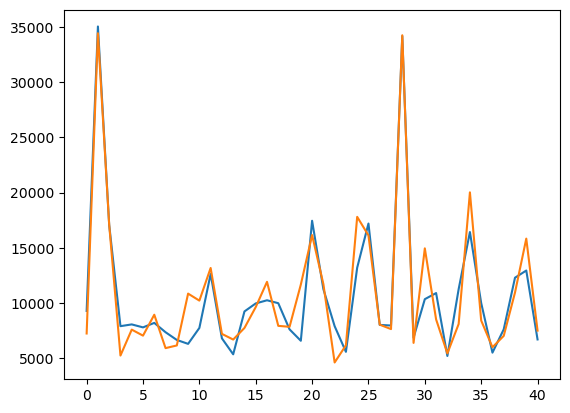

In [77]:
import matplotlib.pyplot as plt

plt.plot(y_test)
plt.plot(y_pred)

In [78]:
lr.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}